## Imports and Setup


In [24]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Data Import

In [25]:
path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")
print(f"✅ Dataset downloaded to: {path}")

# Load key datasets
results      = pd.read_csv(f"{path}/results.csv")
races        = pd.read_csv(f"{path}/races.csv")
drivers      = pd.read_csv(f"{path}/drivers.csv")
constructors = pd.read_csv(f"{path}/constructors.csv")
qualifying   = pd.read_csv(f"{path}/qualifying.csv")
lap_times    = pd.read_csv(f"{path}/lap_times.csv")
pit_stops    = pd.read_csv(f"{path}/pit_stops.csv")

print("\n📦 Datasets loaded:")
datasets = {
    'results': results, 'races': races, 'drivers': drivers,
    'constructors': constructors, 'qualifying': qualifying,
    'lap_times': lap_times, 'pit_stops': pit_stops
}
for name, df in datasets.items():
    print(f"  • {name:15s} → {df.shape[0]:,} rows × {df.shape[1]} cols")

✅ Dataset downloaded to: /Users/colecoli/.cache/kagglehub/datasets/rohanrao/formula-1-world-championship-1950-2020/versions/24

📦 Datasets loaded:
  • results         → 26,759 rows × 18 cols
  • races           → 1,125 rows × 18 cols
  • drivers         → 861 rows × 9 cols
  • constructors    → 212 rows × 5 cols
  • qualifying      → 10,494 rows × 9 cols
  • lap_times       → 589,081 rows × 6 cols
  • pit_stops       → 11,371 rows × 7 cols


## Data Cleaning

In [26]:
# Replace '\N' with NaN across all dataframes
for name, df in datasets.items():
    df.replace('\\N', np.nan, inplace=True)

# Fix data types
results['positionOrder'] = pd.to_numeric(results['positionOrder'], errors='coerce')
results['grid']          = pd.to_numeric(results['grid'],          errors='coerce')
results['points']        = pd.to_numeric(results['points'],        errors='coerce')
results['laps']          = pd.to_numeric(results['laps'],          errors='coerce')
qualifying['position']   = pd.to_numeric(qualifying['position'],   errors='coerce')
races['year']            = pd.to_numeric(races['year'],            errors='coerce')

# Merge results with race metadata
df = results.merge(races[['raceId','year','round','circuitId','name']], on='raceId')
df = df.merge(drivers[['driverId','driverRef','nationality']], on='driverId')
df = df.merge(
    constructors[['constructorId','constructorRef','nationality']]
    .rename(columns={'nationality':'constructor_nationality'}),
    on='constructorId'
)
df = df.merge(
    qualifying[['raceId','driverId','position']]
    .rename(columns={'position':'quali_position'}),
    on=['raceId','driverId'], how='left'
)

# Binary target: did driver WIN?
df['winner'] = (df['positionOrder'] == 1).astype(int)

print(f"✅ Master dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Race winners in dataset: {df['winner'].sum():,}")
print(f"   Unique drivers: {df['driverRef'].nunique()}")
print(f"   Year range: {int(df['year'].min())} – {int(df['year'].max())}")
df.head(3)

✅ Master dataframe: 26,759 rows × 28 columns
   Race winners in dataset: 1,128
   Unique drivers: 861
   Year range: 1950 – 2024


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,year,round,circuitId,name,driverRef,nationality,constructorRef,constructor_nationality,quali_position,winner
0,1,18,1,1,22,1,1,1,1,10.0,...,2008,1,1,Australian Grand Prix,hamilton,British,mclaren,British,1.0,1
1,2,18,2,2,3,5,2,2,2,8.0,...,2008,1,1,Australian Grand Prix,heidfeld,German,bmw_sauber,German,5.0,0
2,3,18,3,3,7,7,3,3,3,6.0,...,2008,1,1,Australian Grand Prix,rosberg,German,williams,British,7.0,0


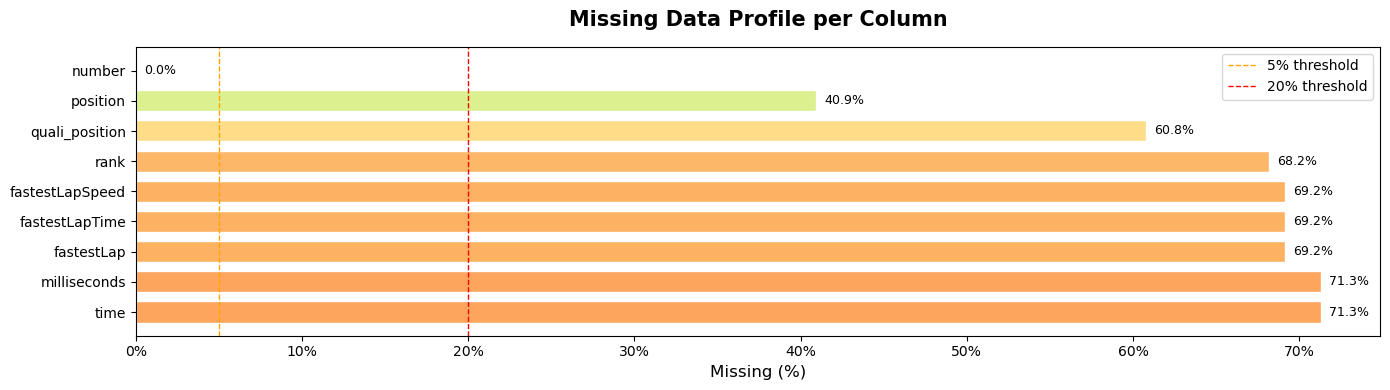

✅ Missing values imputed.


In [27]:
# Missing value bar chart
fig, ax = plt.subplots(figsize=(14, 4))
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

bars = ax.barh(missing_pct.index, missing_pct.values,
               color=plt.cm.RdYlGn_r(missing_pct.values / 100),
               edgecolor='white', height=0.7)
ax.set_xlabel('Missing (%)', fontsize=12)
ax.set_title('Missing Data Profile per Column', fontsize=15, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.axvline(5,  color='orange', linestyle='--', linewidth=1, label='5% threshold')
ax.axvline(20, color='red',    linestyle='--', linewidth=1, label='20% threshold')
ax.legend(fontsize=10)
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('missing_data.png', dpi=150, bbox_inches='tight')
plt.show()

# Impute
df['quali_position'].fillna(df['grid'], inplace=True)
print("✅ Missing values imputed.")

## Explanatory Data Analysis

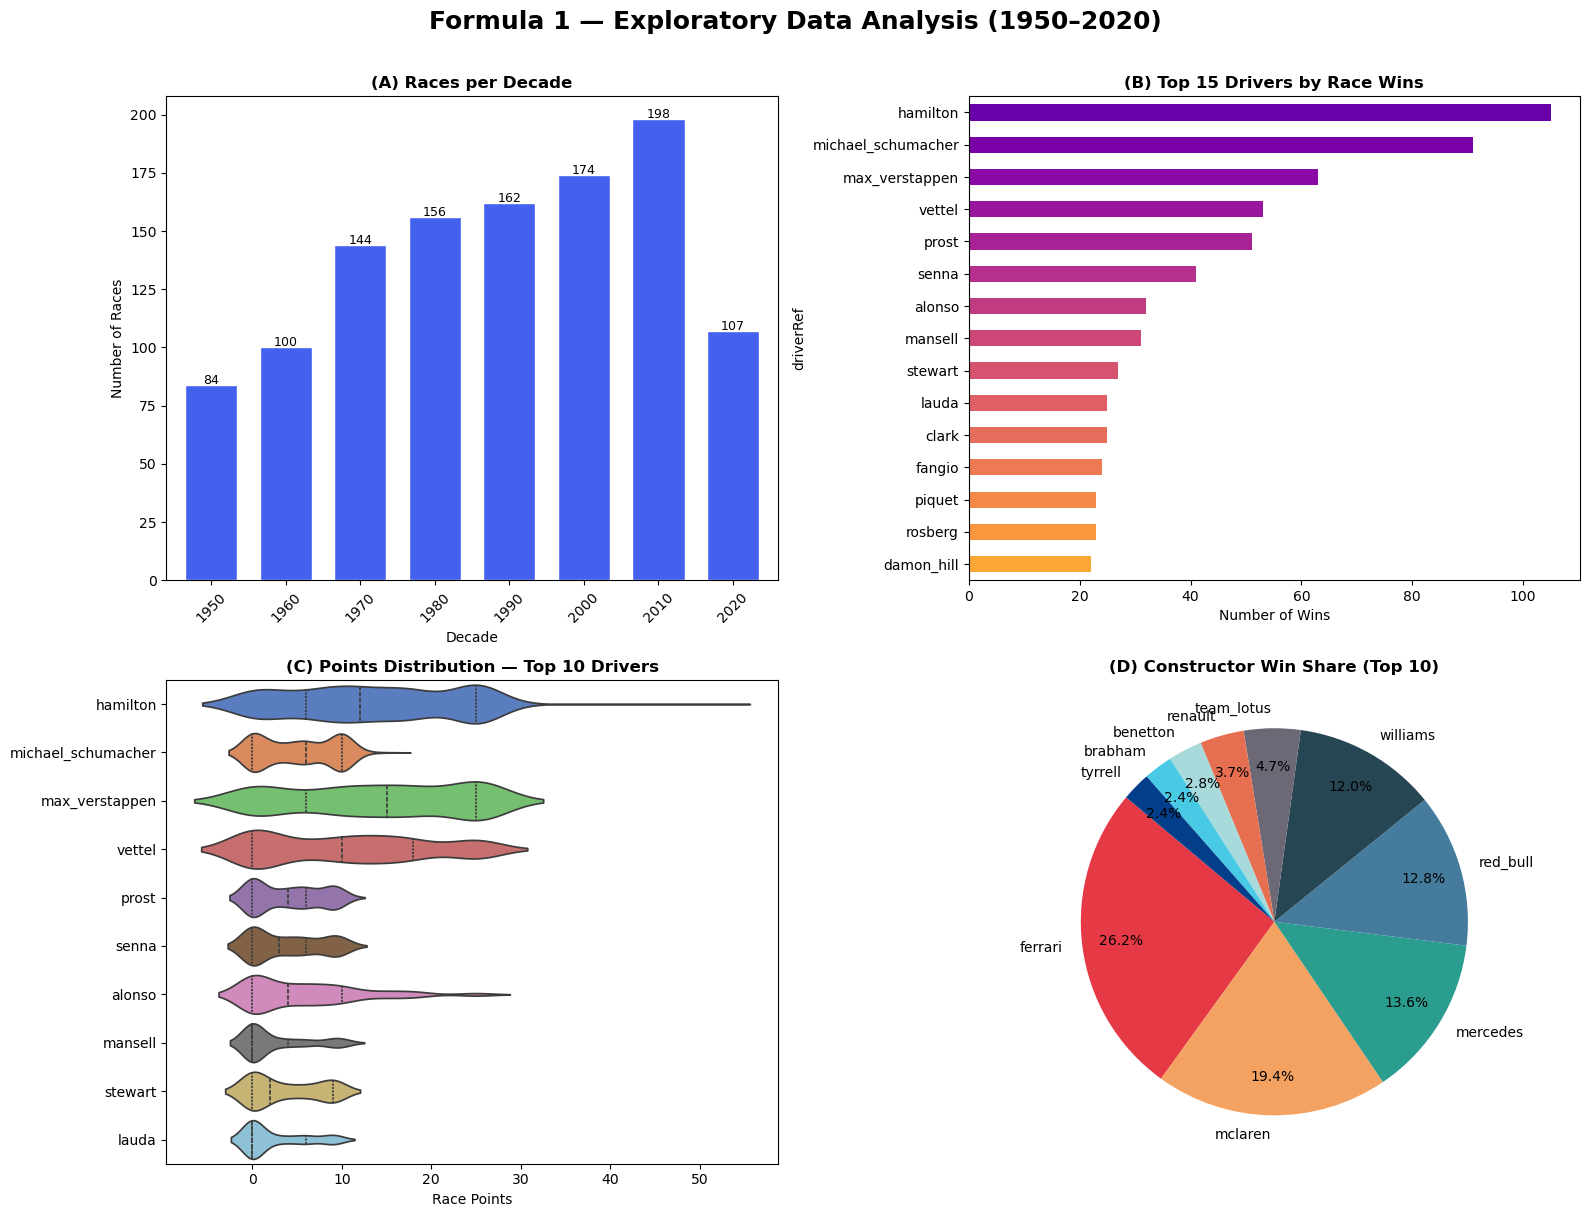

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Formula 1 — Exploratory Data Analysis (1950–2020)',
             fontsize=18, fontweight='bold', y=1.01)

# (A) Races per decade
ax = axes[0, 0]
decade_races = races.groupby(races['year'] // 10 * 10)['raceId'].count()
decade_races.plot(kind='bar', ax=ax, color='#4361ee', edgecolor='white', width=0.7)
ax.set_title('(A) Races per Decade', fontweight='bold')
ax.set_xlabel('Decade'); ax.set_ylabel('Number of Races')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2, p.get_height()+0.5,
            str(int(p.get_height())), ha='center', fontsize=9)

# (B) Top 15 drivers by wins
ax = axes[0, 1]
top_drivers = (df[df['winner']==1]
               .groupby('driverRef')['winner'].sum()
               .sort_values(ascending=False).head(15))
colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(top_drivers)))
top_drivers.plot(kind='barh', ax=ax, color=colors)
ax.set_title('(B) Top 15 Drivers by Race Wins', fontweight='bold')
ax.set_xlabel('Number of Wins')
ax.invert_yaxis()

# (C) Points distribution violin
ax = axes[1, 0]
top10_drivers = top_drivers.head(10).index
plot_data = df[df['driverRef'].isin(top10_drivers)]
sns.violinplot(data=plot_data, y='driverRef', x='points', ax=ax,
               order=top10_drivers, palette='muted', inner='quartile')
ax.set_title('(C) Points Distribution — Top 10 Drivers', fontweight='bold')
ax.set_xlabel('Race Points'); ax.set_ylabel('')

# (D) Constructor wins pie
ax = axes[1, 1]
top_teams = (df[df['winner']==1]
             .groupby('constructorRef')['winner'].sum()
             .sort_values(ascending=False).head(10))
team_colors = ['#e63946','#f4a261','#2a9d8f','#457b9d','#264653',
               '#6d6875','#e76f51','#a8dadc','#48cae4','#023e8a']
ax.pie(top_teams.values, labels=top_teams.index, autopct='%1.1f%%',
       colors=team_colors, startangle=140, pctdistance=0.8)
ax.set_title('(D) Constructor Win Share (Top 10)', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Qualifying vs Performance

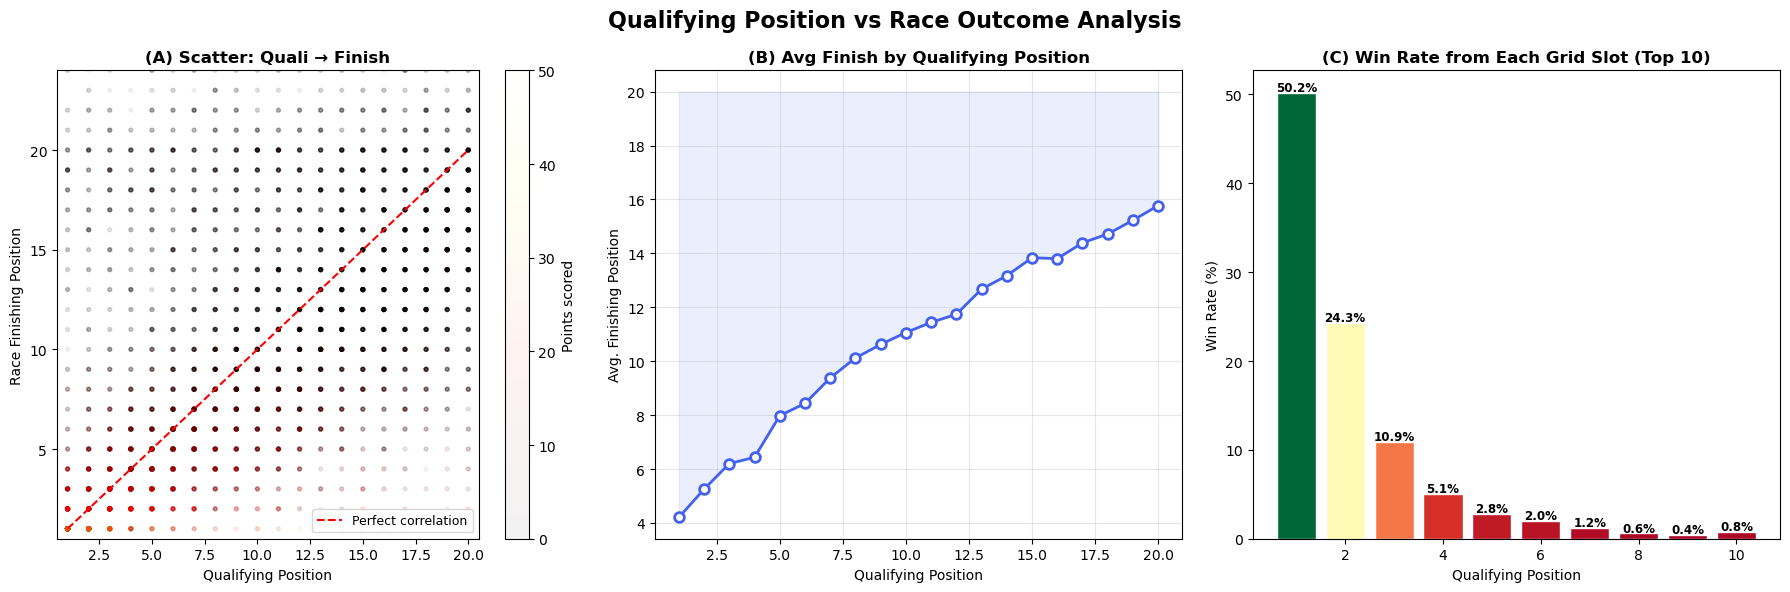


📈 Correlation (Quali → Race Position): 0.576


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Qualifying Position vs Race Outcome Analysis',
             fontsize=16, fontweight='bold')

plot_df = df[df['quali_position'].notna() & df['positionOrder'].notna()].copy()
plot_df['quali_position'] = pd.to_numeric(plot_df['quali_position'])
plot_df['positionOrder']  = pd.to_numeric(plot_df['positionOrder'])

# (A) Scatter density
ax = axes[0]
sc = ax.scatter(plot_df['quali_position'], plot_df['positionOrder'],
                alpha=0.05, c=plot_df['points'], cmap='hot', s=8)
ax.plot([1,20],[1,20], 'r--', linewidth=1.5, label='Perfect correlation')
plt.colorbar(sc, ax=ax, label='Points scored')
ax.set_xlabel('Qualifying Position'); ax.set_ylabel('Race Finishing Position')
ax.set_title('(A) Scatter: Quali → Finish', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0.5, 20.5); ax.set_ylim(0.5, 24)

# (B) Average finish per quali position
ax = axes[1]
avg_finish = (plot_df[plot_df['quali_position'] <= 20]
              .groupby('quali_position')['positionOrder'].mean())
ax.plot(avg_finish.index, avg_finish.values, 'o-',
        color='#4361ee', linewidth=2, markersize=7,
        markerfacecolor='white', markeredgewidth=2)
ax.fill_between(avg_finish.index, avg_finish.values, 20,
                alpha=0.1, color='#4361ee')
ax.set_xlabel('Qualifying Position'); ax.set_ylabel('Avg. Finishing Position')
ax.set_title('(B) Avg Finish by Qualifying Position', fontweight='bold')
ax.grid(True, alpha=0.3)

# (C) Win rate per qualifying position
ax = axes[2]
win_rate = (plot_df[plot_df['quali_position'] <= 10]
            .groupby('quali_position')['winner'].mean() * 100)
colors_wr = plt.cm.RdYlGn(win_rate.values / win_rate.max())
bars = ax.bar(win_rate.index, win_rate.values, color=colors_wr, edgecolor='white')
ax.set_xlabel('Qualifying Position'); ax.set_ylabel('Win Rate (%)')
ax.set_title('(C) Win Rate from Each Grid Slot (Top 10)', fontweight='bold')
for bar, val in zip(bars, win_rate.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{val:.1f}%', ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('quali_vs_race.png', dpi=150, bbox_inches='tight')
plt.show()

corr = plot_df[['quali_position','positionOrder','grid','points']].corr()
print(f"\n📈 Correlation (Quali → Race Position): {corr.loc['quali_position','positionOrder']:.3f}")

### Feature Engineering


In [30]:
df_fe = df.copy()
df_fe = df_fe.sort_values(['driverId','year','round']).reset_index(drop=True)

# Rolling 5-race driver form
df_fe['driver_rolling_wins'] = (
    df_fe.groupby('driverId')['winner']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum()))

df_fe['driver_rolling_points'] = (
    df_fe.groupby('driverId')['points']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()))

# Cumulative career wins
df_fe['driver_career_wins'] = (
    df_fe.groupby('driverId')['winner']
    .transform(lambda x: x.shift(1).cumsum().fillna(0)))

# Constructor rolling form
df_fe = df_fe.sort_values(['constructorId','year','round'])
df_fe['constructor_rolling_wins'] = (
    df_fe.groupby('constructorId')['winner']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).sum()))

# Season progress
max_round = df_fe.groupby(['year'])['round'].transform('max')
df_fe['season_progress'] = df_fe['round'] / max_round

# Final feature set
feature_cols = [
    'grid', 'quali_position',
    'driver_rolling_wins', 'driver_rolling_points', 'driver_career_wins',
    'constructor_rolling_wins', 'season_progress'
]
df_model = df_fe[feature_cols + ['winner']].dropna()

print(f"✅ Feature engineering complete.")
print(f"   Training-ready samples: {len(df_model):,}")
print(f"   Features: {feature_cols}")
df_model.describe().round(2)

✅ Feature engineering complete.
   Training-ready samples: 10,346
   Features: ['grid', 'quali_position', 'driver_rolling_wins', 'driver_rolling_points', 'driver_career_wins', 'constructor_rolling_wins', 'season_progress']


,grid,quali_position,driver_rolling_wins,driver_rolling_points,driver_career_wins,constructor_rolling_wins,season_progress,winner
count,10346.00,10346.00,10346.00,10346.00,10346.00,10346.00,10346.00,10346.00
mean,10.96,11.12,0.24,3.58,7.23,0.24,0.52,0.05
std,6.27,6.24,0.71,4.97,17.05,0.61,0.29,0.21
min,0.00,1.00,0.00,0.00,0.00,0.00,0.04,0.00
25%,6.00,6.00,0.00,0.00,0.00,0.00,0.26,0.00
50%,11.00,11.00,0.00,1.40,0.00,0.00,0.52,0.00
75%,16.00,16.00,0.00,5.00,6.00,0.00,0.76,0.00
max,26.00,28.00,5.00,28.60,105.00,3.00,1.00,1.00


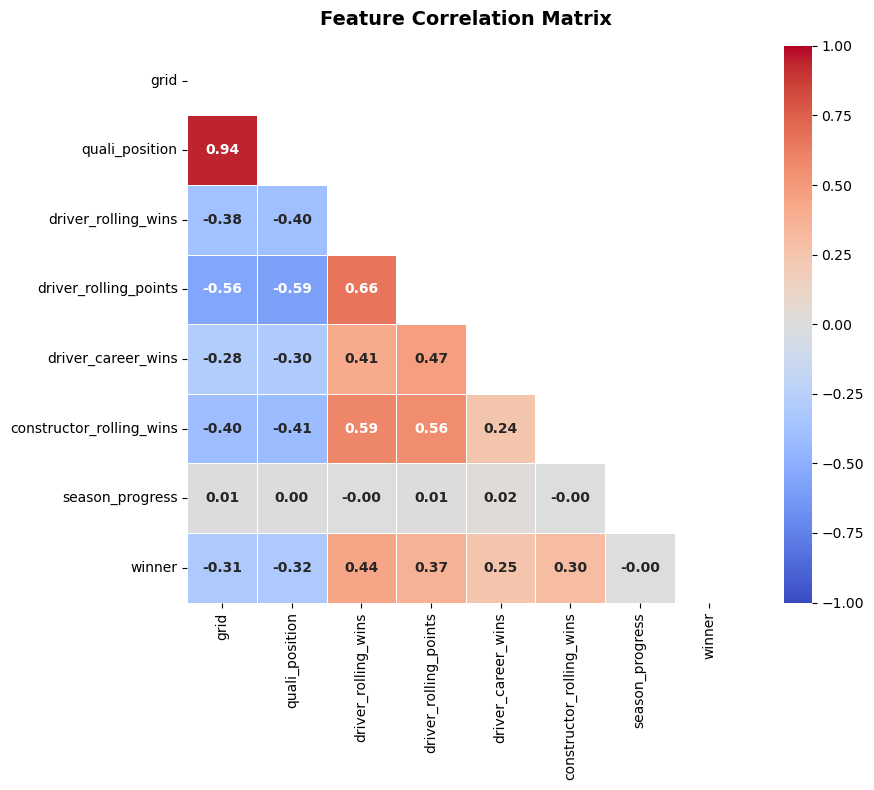

In [31]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_model.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 5: Model Training & Evaluation


In [32]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              precision_score, recall_score, classification_report)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("ℹ️  XGBoost not installed; using GradientBoosting as substitute.")

X = df_model[feature_cols].values
y = df_model['winner'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

scale_pos = (len(y_train) - y_train.sum()) / y_train.sum()

models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced',
                                               max_iter=500, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                                   max_depth=8, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                       learning_rate=0.05, random_state=42),
}
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.05,
                                       scale_pos_weight=scale_pos, use_label_encoder=False,
                                       eval_metric='logloss', random_state=42)

results_dict = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
colors = ['#e63946','#4361ee','#2a9d8f','#f4a261']

for name, model in models.items():
    Xtr = X_train_sc if name == 'Logistic Regression' else X_train
    Xte = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(Xtr, y_train)
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:,1]
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv,
                                 scoring='roc_auc', n_jobs=-1)
    results_dict[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        'CV-AUC':    f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
    }
    print(f"✅ {name} trained.")

results_table = pd.DataFrame(results_dict).T
print("\n📊 Model Performance Summary:")
results_table.round(4)

✅ Logistic Regression trained.
✅ Random Forest trained.
✅ Gradient Boosting trained.
✅ XGBoost trained.

📊 Model Performance Summary:


,Accuracy,Precision,Recall,F1,ROC-AUC,CV-AUC
Logistic Regression,0.849275,0.229008,0.909091,0.365854,0.942684,0.944 ± 0.008
Random Forest,0.921739,0.361233,0.828283,0.503067,0.945938,0.942 ± 0.012
Gradient Boosting,0.950725,0.471698,0.252525,0.328947,0.938577,0.940 ± 0.011
XGBoost,0.904348,0.313208,0.838384,0.456044,0.939758,0.935 ± 0.009


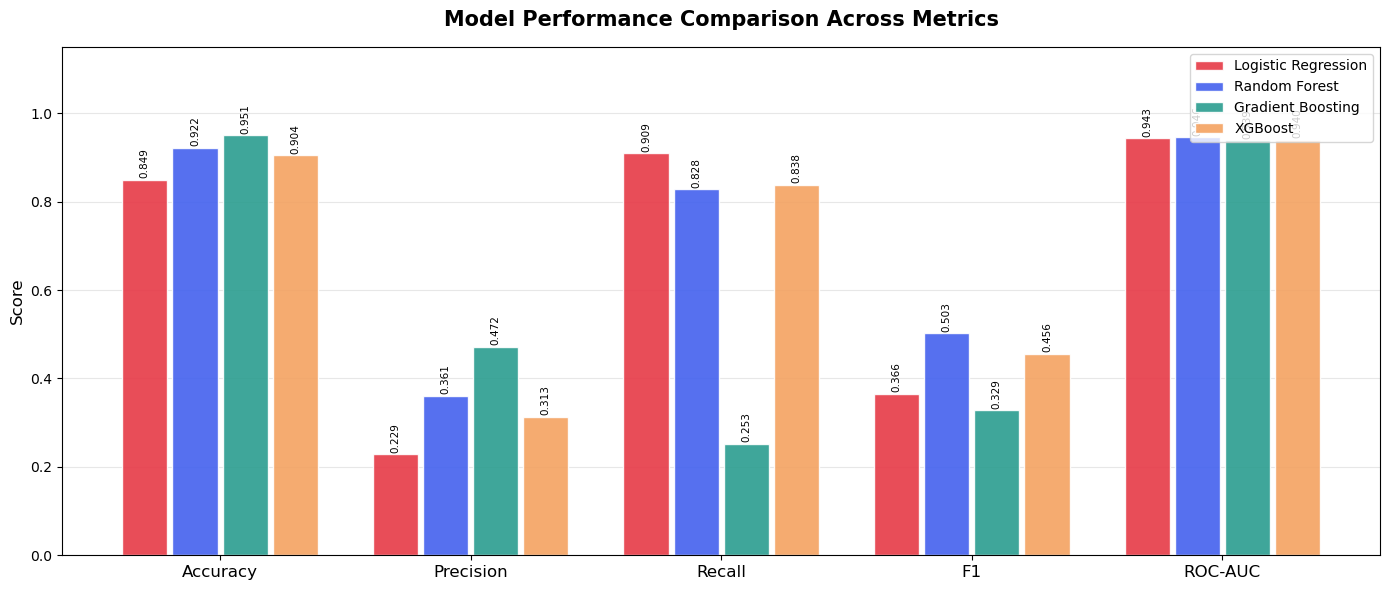

In [33]:
# Model performance comparison bar chart
metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
results_numeric = results_table[metrics].astype(float)

fig, ax = plt.subplots(figsize=(14, 6))
x     = np.arange(len(metrics))
width = 0.8 / len(results_numeric)

for i, (model_name, row) in enumerate(results_numeric.iterrows()):
    offset = (i - len(results_numeric)/2 + 0.5) * width
    bars = ax.bar(x + offset, row.values, width*0.9,
                  label=model_name, color=colors[i], alpha=0.9, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=7.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison Across Metrics',
             fontsize=15, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Model Evaluation


🏆 Best model: Random Forest (ROC-AUC: 0.9459)

              precision    recall  f1-score   support

  Non-Winner       0.99      0.93      0.96      1971
      Winner       0.36      0.83      0.50        99

    accuracy                           0.92      2070
   macro avg       0.68      0.88      0.73      2070
weighted avg       0.96      0.92      0.94      2070



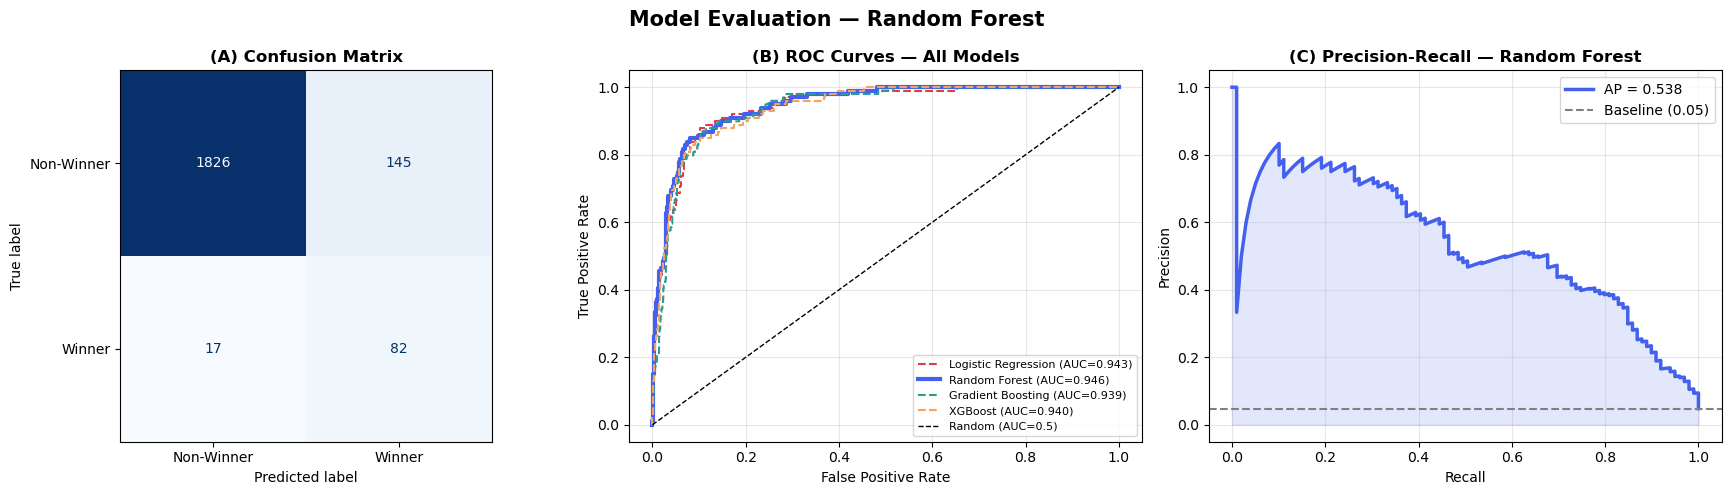

In [34]:
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              precision_recall_curve, average_precision_score,
                              ConfusionMatrixDisplay)

# Best model by ROC-AUC
best_name  = results_numeric['ROC-AUC'].idxmax()
best_model = models[best_name]
Xte_best   = X_test_sc if best_name == 'Logistic Regression' else X_test
y_proba_best = best_model.predict_proba(Xte_best)[:,1]
y_pred_best  = best_model.predict(Xte_best)

print(f"🏆 Best model: {best_name} (ROC-AUC: {results_numeric.loc[best_name,'ROC-AUC']:.4f})")
print("\n" + classification_report(y_test, y_pred_best,
                                    target_names=['Non-Winner','Winner']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Model Evaluation — {best_name}', fontsize=15, fontweight='bold')

# (A) Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=['Non-Winner','Winner']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('(A) Confusion Matrix', fontweight='bold')

# (B) ROC Curves — all models
ax = axes[1]
for (name, model), color in zip(models.items(), colors):
    Xte_m = X_test_sc if name == 'Logistic Regression' else X_test
    yp = model.predict_proba(Xte_m)[:,1]
    fpr, tpr, _ = roc_curve(y_test, yp)
    auc_score   = auc(fpr, tpr)
    lw = 3 if name == best_name else 1.5
    ax.plot(fpr, tpr, color=color, linewidth=lw,
            label=f'{name} (AUC={auc_score:.3f})',
            linestyle='-' if name == best_name else '--')
ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('(B) ROC Curves — All Models', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (C) Precision-Recall Curve
ax = axes[2]
prec, rec, _ = precision_recall_curve(y_test, y_proba_best)
ap = average_precision_score(y_test, y_proba_best)
ax.plot(rec, prec, color='#4361ee', linewidth=2.5, label=f'AP = {ap:.3f}')
ax.fill_between(rec, prec, alpha=0.15, color='#4361ee')
baseline = y_test.sum() / len(y_test)
ax.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.2f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'(C) Precision-Recall — {best_name}', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

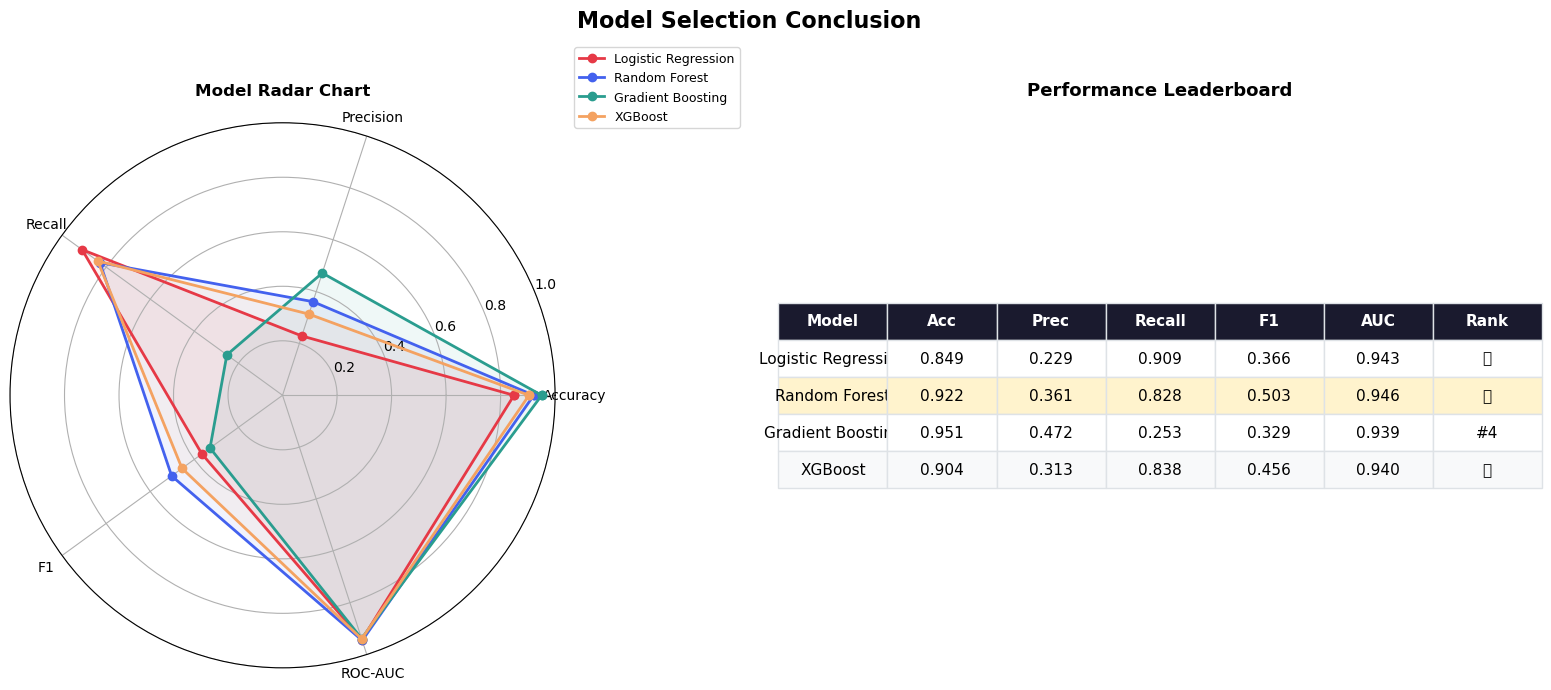


🏆 WINNER: Random Forest
   ROC-AUC : 0.9459
   F1-Score: 0.5031


In [35]:
fig = plt.figure(figsize=(16, 7))
fig.suptitle('Model Selection Conclusion', fontsize=16, fontweight='bold')

# Radar chart
ax = plt.subplot(121, polar=True)
radar_metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
N      = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for i, (name, row) in enumerate(results_numeric.iterrows()):
    values  = row[radar_metrics].tolist() + [row[radar_metrics[0]]]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=name)
    ax.fill(angles, values, alpha=0.07, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Model Radar Chart', fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

# Leaderboard table
ax2 = plt.subplot(122)
ax2.axis('off')
col_labels = ['Model','Acc','Prec','Recall','F1','AUC','Rank']
medals     = {1:'🥇', 2:'🥈', 3:'🥉'}
ranked     = results_numeric['ROC-AUC'].rank(ascending=False).astype(int)
table_data = []
for name, row in results_numeric.iterrows():
    table_data.append([
        name,
        f"{row['Accuracy']:.3f}", f"{row['Precision']:.3f}",
        f"{row['Recall']:.3f}",   f"{row['F1']:.3f}",
        f"{row['ROC-AUC']:.3f}",  medals.get(ranked[name], f"#{ranked[name]}")
    ])

table = ax2.table(cellText=table_data, colLabels=col_labels,
                   loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.2)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color='white', fontweight='bold')
    elif table_data[r-1][-1] == '🥇':
        cell.set_facecolor('#fff3cd')
    elif r % 2 == 0:
        cell.set_facecolor('#f8f9fa')
    cell.set_edgecolor('#dee2e6')
ax2.set_title('Performance Leaderboard', fontweight='bold', fontsize=13, pad=20)

plt.tight_layout()
plt.savefig('model_conclusion.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n🏆 WINNER: {best_name}")
print(f"   ROC-AUC : {results_numeric.loc[best_name,'ROC-AUC']:.4f}")
print(f"   F1-Score: {results_numeric.loc[best_name,'F1']:.4f}")

### Important Analysis


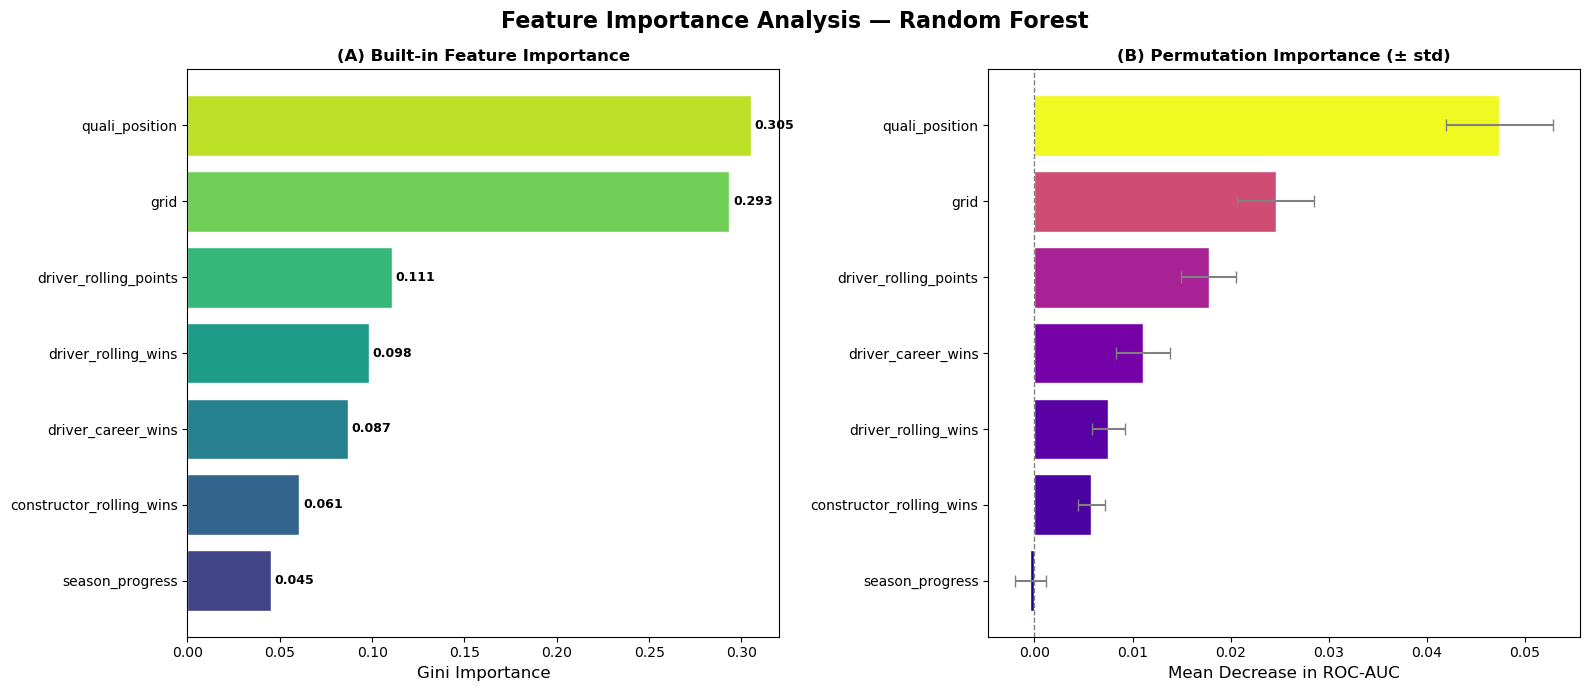


🔑 Top 3 Most Predictive Features:
  1. quali_position: 0.3052
  2. grid: 0.2935
  3. driver_rolling_points: 0.1106


In [36]:
from sklearn.inspection import permutation_importance

tree_model = models.get('Random Forest') or models.get('Gradient Boosting')
tree_name  = 'Random Forest' if 'Random Forest' in models else 'Gradient Boosting'

# Built-in Gini importance
fi = pd.Series(tree_model.feature_importances_,
               index=feature_cols).sort_values(ascending=False)

# Permutation importance
perm_imp = permutation_importance(tree_model, X_test, y_test,
                                   n_repeats=30, random_state=42,
                                   scoring='roc_auc')
perm_mean = perm_imp.importances_mean
perm_std  = perm_imp.importances_std

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f'Feature Importance Analysis — {tree_name}',
             fontsize=16, fontweight='bold')

# (A) Gini importance
ax = axes[0]
colors_fi = plt.cm.viridis(np.linspace(0.2, 0.9, len(fi)))
bars = ax.barh(fi.index[::-1], fi.values[::-1], color=colors_fi, edgecolor='white')
ax.set_xlabel('Gini Importance', fontsize=12)
ax.set_title('(A) Built-in Feature Importance', fontweight='bold')
for bar, val in zip(bars, fi.values[::-1]):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# (B) Permutation importance
ax = axes[1]
sort_idx = np.argsort(perm_mean)
ax.barh(np.array(feature_cols)[sort_idx], perm_mean[sort_idx],
        xerr=perm_std[sort_idx],
        color=plt.cm.plasma(perm_mean[sort_idx]/perm_mean.max()),
        edgecolor='white', capsize=4,
        error_kw={'elinewidth':1.5, 'ecolor':'gray'})
ax.set_xlabel('Mean Decrease in ROC-AUC', fontsize=12)
ax.set_title('(B) Permutation Importance (± std)', fontweight='bold')
ax.axvline(0, color='gray', linewidth=1, linestyle='--')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🔑 Top 3 Most Predictive Features:")
for i, (feat, imp) in enumerate(fi.head(3).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

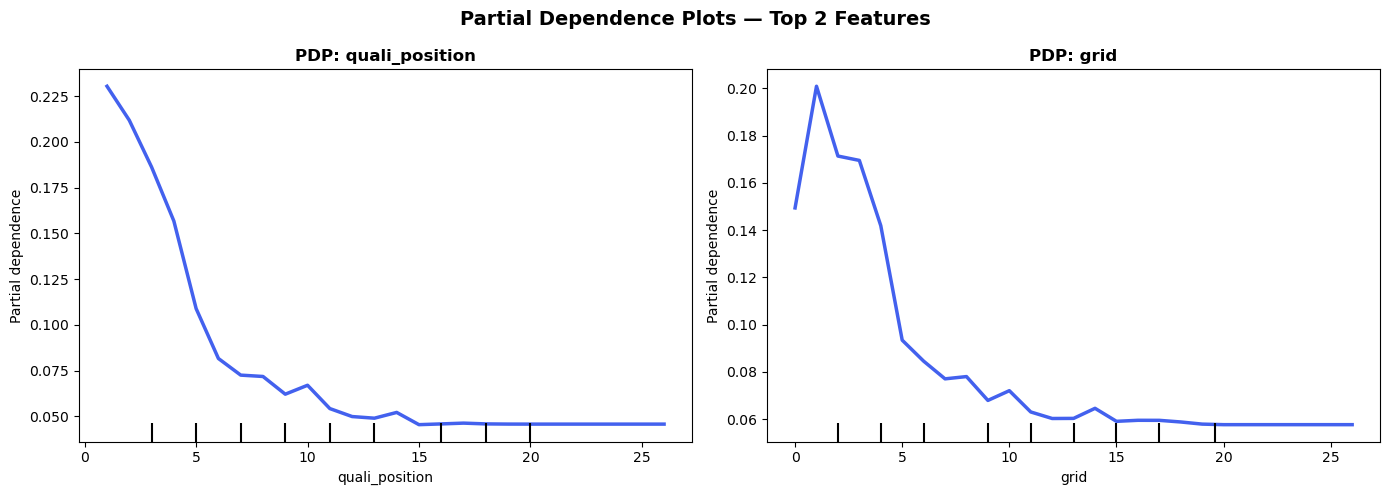

In [37]:
# Partial Dependence Plots
from sklearn.inspection import PartialDependenceDisplay

top2_idx = [feature_cols.index(f) for f in fi.head(2).index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Partial Dependence Plots — Top 2 Features',
             fontsize=14, fontweight='bold')

for i, feat_idx in enumerate(top2_idx):
    PartialDependenceDisplay.from_estimator(
        tree_model, X_test, [feat_idx],
        feature_names=feature_cols,
        ax=axes[i],
        line_kw={'color':'#4361ee', 'linewidth':2.5}
    )
    axes[i].set_title(f'PDP: {feature_cols[feat_idx]}', fontweight='bold')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('partial_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

### 8. Driver Champion Prediction (Named Drivers)

In [51]:
CHAMPION_DRIVERS = [
    'hamilton', 'max_verstappen', 'michael_schumacher', 'vettel',
    'alonso', 'raikkonen', 'button', 'rosberg',
    'prost', 'senna', 'piquet', 'lauda',
    'hill', 'mansell', 'stewart', 'clark',
    # Schumacher-era and 2000s rivals
    'villeneuve', 'hakkinen', 'coulthard', 'massa',
    # Current/Verstappen-era rivals
    'bottas', 'leclerc', 'perez', 'norris', 'sainz', 'russell'
]
,
# Season-level aggregation (same as before)
season_df = df_fe.copy()
season_df['points'] = pd.to_numeric(season_df['points'], errors='coerce')

season_agg = season_df.groupby(['year','driverId','driverRef']).agg(
    total_points     = ('points',         'sum'),
    total_wins       = ('winner',         'sum'),
    races_entered    = ('raceId',         'count'),
    avg_finish       = ('positionOrder',  'mean'),
    avg_grid         = ('grid',           'mean'),
    avg_quali        = ('quali_position', 'mean'),
    podiums          = ('positionOrder',  lambda x: (x <= 3).sum()),
    dnf_count        = ('positionOrder',  lambda x: (x > 20).sum()),
    best_constructor = ('constructorRef', lambda x: x.mode()[0]),
).reset_index()

# Mark the actual season champion
season_agg['season_champion'] = (
    season_agg.groupby('year')['total_points']
    .transform(lambda x: (x == x.max()).astype(int))
)

# Derived rate features
season_agg['win_rate']        = season_agg['total_wins']    / season_agg['races_entered']
season_agg['podium_rate']     = season_agg['podiums']        / season_agg['races_entered']
season_agg['dnf_rate']        = season_agg['dnf_count']      / season_agg['races_entered']
season_agg['points_per_race'] = season_agg['total_points']   / season_agg['races_entered']

# Filter to only known champion-level (or elite) drivers
champ_driver_df = season_agg[season_agg['driverRef'].isin(CHAMPION_DRIVERS)].copy()

print(f"✅ Driver-season records for named drivers: {len(champ_driver_df)}")
print(f"   Drivers found: {sorted(champ_driver_df['driverRef'].unique())}")
champ_driver_df[['driverRef','year','total_wins','total_points',
                  'podiums','win_rate','season_champion']].head(10)

✅ Driver-season records for named drivers: 341
   Drivers found: ['alonso', 'bottas', 'button', 'clark', 'coulthard', 'hakkinen', 'hamilton', 'hill', 'lauda', 'leclerc', 'mansell', 'massa', 'max_verstappen', 'michael_schumacher', 'norris', 'perez', 'piquet', 'prost', 'raikkonen', 'rosberg', 'russell', 'sainz', 'senna', 'stewart', 'vettel', 'villeneuve']


,driverRef,year,total_wins,total_points,podiums,win_rate,season_champion
720,hill,1958,0,0.0,0,0.000000,0
807,hill,1959,0,0.0,0,0.000000,0
895,hill,1960,0,4.0,1,0.000000,0
902,clark,1960,0,8.0,1,0.000000,0
986,hill,1961,0,3.0,0,0.000000,0
992,clark,1961,0,11.0,2,0.000000,0
1048,hill,1962,4,52.0,6,0.444444,1
1057,clark,1962,3,30.0,3,0.333333,0
1110,hill,1963,2,29.0,5,0.200000,0
1123,clark,1963,7,73.0,9,0.700000,1


### Training

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, auc)

champ_features = [
    'total_wins', 'total_points', 'win_rate', 'podium_rate',
    'dnf_rate', 'avg_finish', 'avg_grid', 'avg_quali',
    'points_per_race', 'races_entered'
]

model_df = champ_driver_df[champ_features + ['season_champion']].dropna()
Xc = model_df[champ_features].values
yc = model_df['season_champion'].values

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, stratify=yc, random_state=42)

champ_model = RandomForestClassifier(
    n_estimators=300, max_depth=6,
    class_weight='balanced', random_state=42, n_jobs=-1)
champ_model.fit(Xc_train, yc_train)

yc_pred  = champ_model.predict(Xc_test)
yc_proba = champ_model.predict_proba(Xc_test)[:,1]

print("🏆 Champion Prediction — Classification Report:")
print(classification_report(yc_test, yc_pred,
                             target_names=['Not Champion','Champion']))
print(f"ROC-AUC: {roc_auc_score(yc_test, yc_proba):.4f}")

🏆 Champion Prediction — Classification Report:
              precision    recall  f1-score   support

Not Champion       1.00      0.95      0.98        42
    Champion       0.75      1.00      0.86         6

    accuracy                           0.96        48
   macro avg       0.88      0.98      0.92        48
weighted avg       0.97      0.96      0.96        48

ROC-AUC: 1.0000


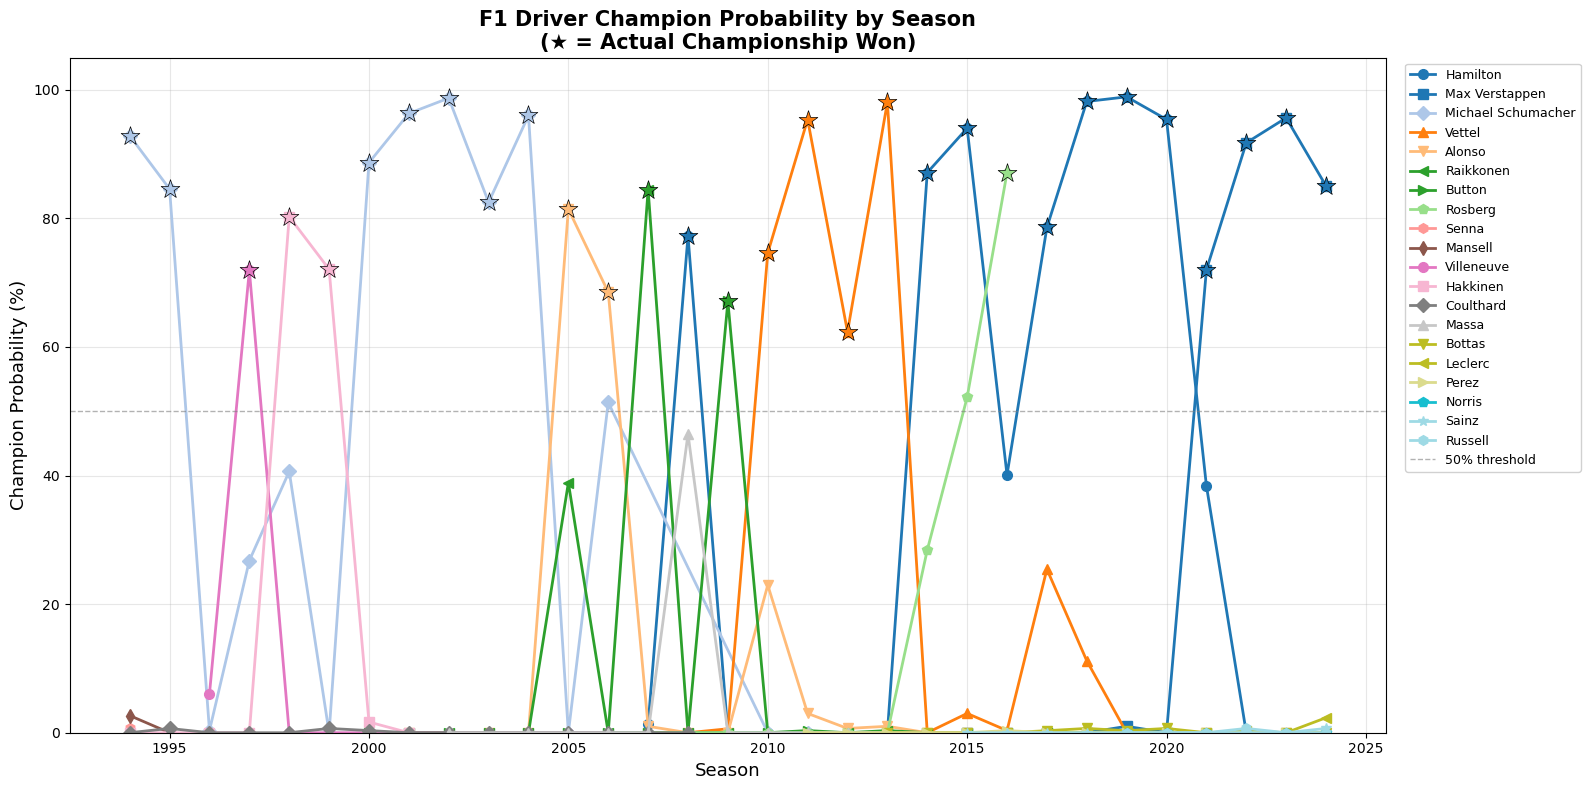

Figure 11: Champion Probability Timeline — Named Drivers (★ = won that year)


In [53]:
# ── Per-driver career champion probability timeline ────────────
champ_driver_df = champ_driver_df.dropna(subset=champ_features).copy()
champ_driver_df['champ_prob'] = champ_model.predict_proba(
    champ_driver_df[champ_features].values)[:,1] * 100

# Plot: one line per driver across their career seasons
fig, ax = plt.subplots(figsize=(16, 8))

driver_colors = plt.cm.tab20(np.linspace(0, 1, len(CHAMPION_DRIVERS)))
markers = ['o','s','D','^','v','<','>','p','*','h','H','+','x','d','|','_']

for i, driver in enumerate(CHAMPION_DRIVERS):
    d = champ_driver_df[champ_driver_df['driverRef'] == driver].sort_values('year')
    if d.empty:
        continue
    ax.plot(d['year'], d['champ_prob'],
            color=driver_colors[i], linewidth=2,
            marker=markers[i % len(markers)], markersize=7,
            label=driver.replace('_',' ').title())

    # Star on actual championship seasons
    champ_seasons = d[d['season_champion'] == 1]
    ax.scatter(champ_seasons['year'], champ_seasons['champ_prob'],
               color=driver_colors[i], s=200, marker='*',
               zorder=5, edgecolors='black', linewidths=0.5)

ax.axhline(50, color='gray', linestyle='--', linewidth=1,
           alpha=0.6, label='50% threshold')
ax.set_xlabel('Season', fontsize=13)
ax.set_ylabel('Champion Probability (%)', fontsize=13)
ax.set_title('F1 Driver Champion Probability by Season\n(★ = Actual Championship Won)',
             fontsize=15, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.savefig('champion_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11: Champion Probability Timeline — Named Drivers (★ = won that year)")

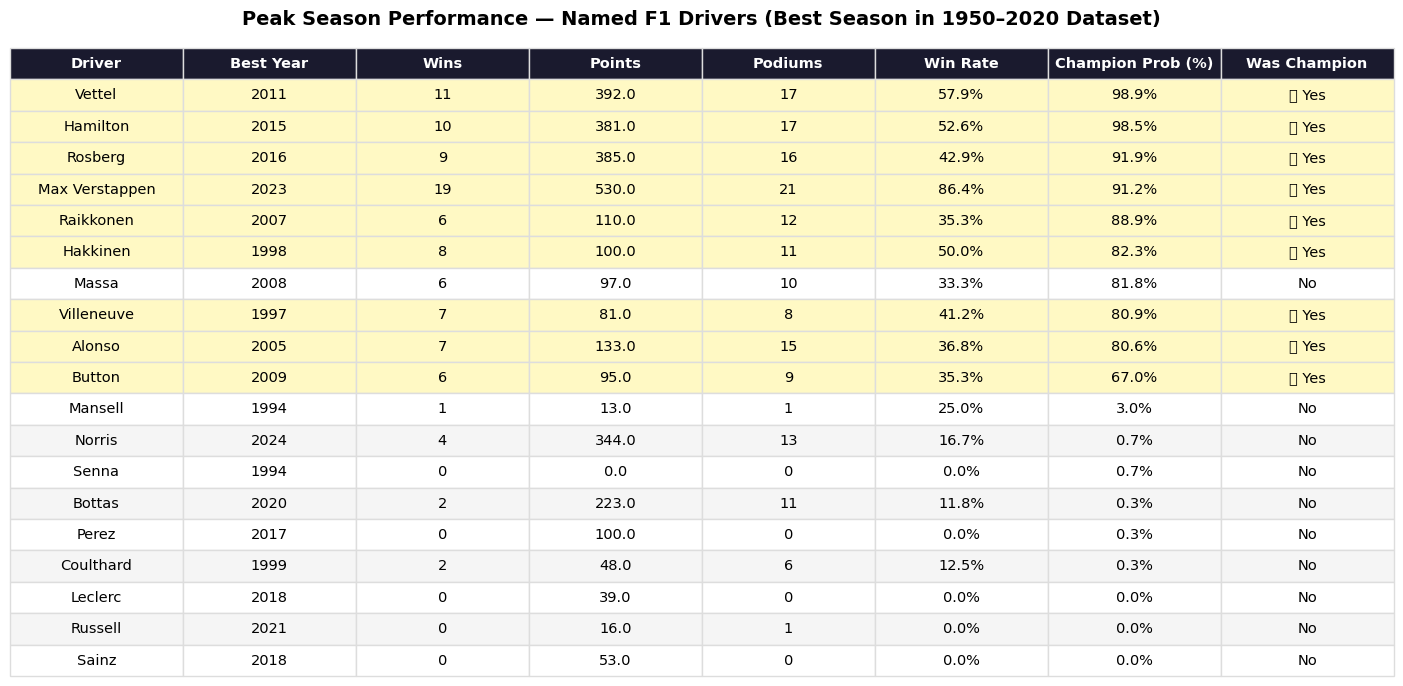

Figure 12: Named Driver Peak Season Table (Best Season in 1950–2020 Dataset)


In [48]:
# ── Peak season stats table per driver ────────────────────────
peak = (champ_driver_df
        .sort_values('champ_prob', ascending=False)
        .groupby('driverRef')
        .first()
        .reset_index()
        .sort_values('champ_prob', ascending=False)[
            ['driverRef','year','total_wins','total_points',
             'podiums','win_rate','champ_prob','season_champion']
        ])
peak.columns = ['Driver','Best Year','Wins','Points',
                'Podiums','Win Rate','Champion Prob (%)','Was Champion']
peak['Win Rate']          = peak['Win Rate'].map('{:.1%}'.format)
peak['Champion Prob (%)'] = peak['Champion Prob (%)'].map('{:.1f}%'.format)
peak['Was Champion']      = peak['Was Champion'].map({1:'🏆 Yes', 0:'No'})
peak['Driver']            = peak['Driver'].str.replace('_',' ').str.title()

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('off')
table = ax.table(
    cellText=peak.values,
    colLabels=peak.columns,
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10.5)
table.scale(1.2, 2.0)

for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color='white', fontweight='bold')
    elif peak.iloc[r-1]['Was Champion'] == '🏆 Yes' if r > 0 else False:
        cell.set_facecolor('#fff9c4')
    elif r % 2 == 0:
        cell.set_facecolor('#f5f5f5')
    cell.set_edgecolor('#dddddd')

ax.set_title('Peak Season Performance — Named F1 Drivers (Best Season in 1950–2020 Dataset)',
             fontsize=14, fontweight='bold', pad=60)
plt.tight_layout()
plt.savefig('champion_table.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 12: Named Driver Peak Season Table (Best Season in 1950–2020 Dataset)")

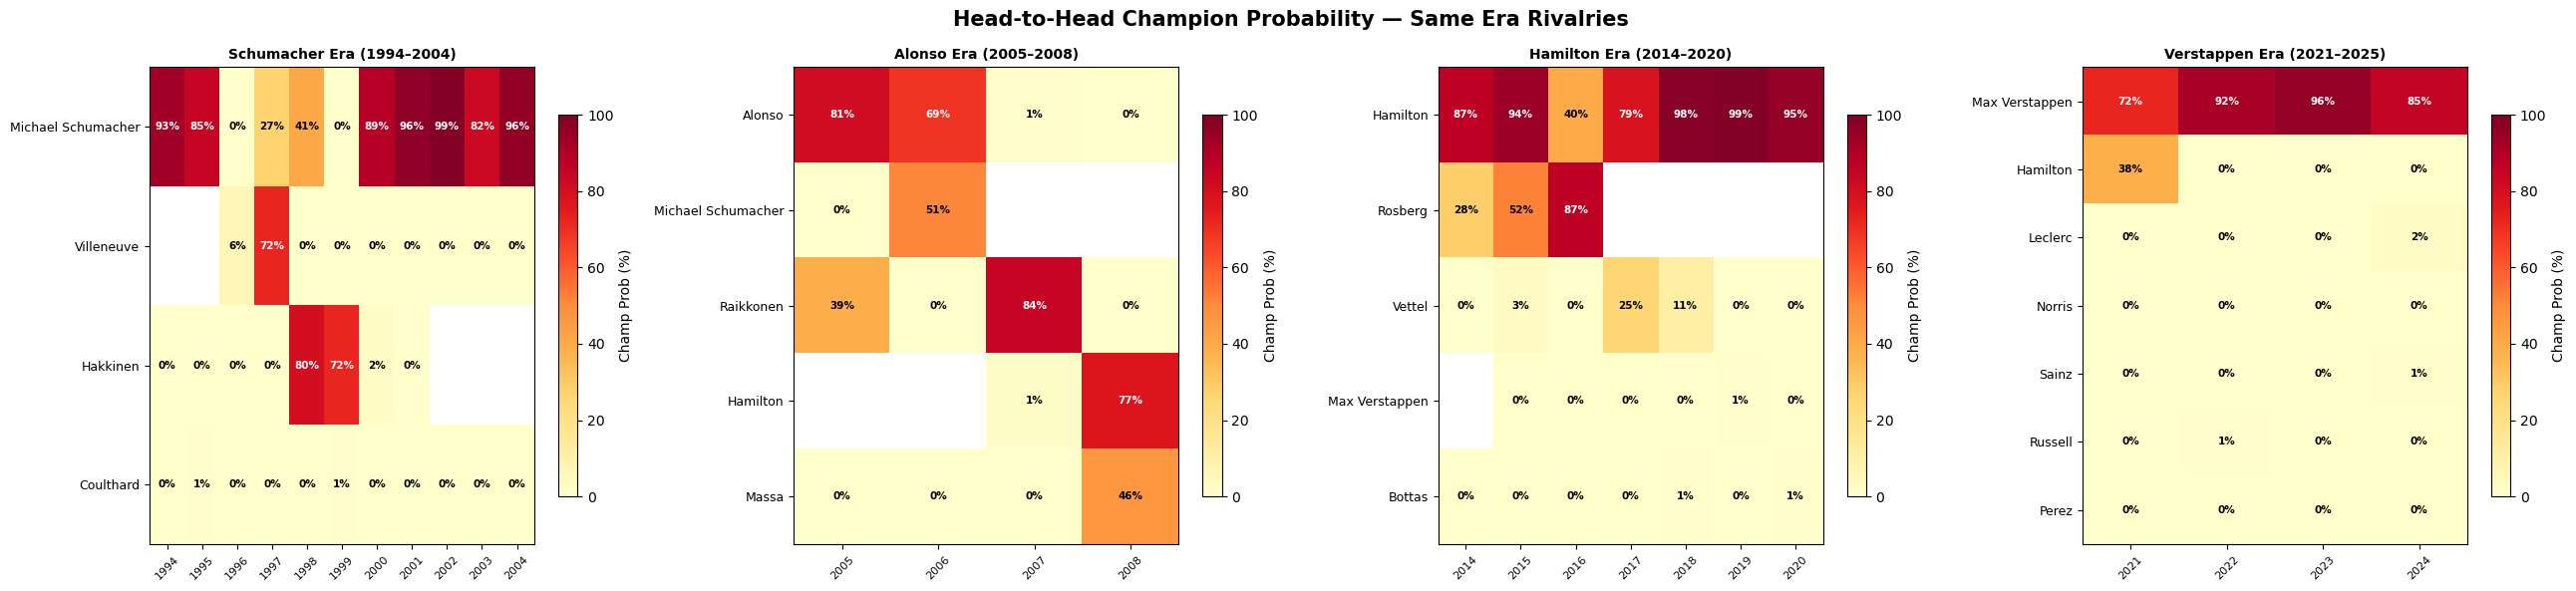

Figure 13: Era Rivalry Heatmaps


In [54]:
# ── Head-to-head: same-era drivers ────────────────────────────
ERA_BATTLES = {
    'Schumacher Era (1994–2004)': ['michael_schumacher','hill','villeneuve','hakkinen','coulthard'],
    'Alonso Era (2005–2008)':     ['alonso','michael_schumacher','raikkonen','hamilton','massa'],
    'Hamilton Era (2014–2020)':   ['hamilton','rosberg','vettel','max_verstappen','bottas'],
    'Verstappen Era (2021–2025)': ['max_verstappen','hamilton','leclerc','norris','sainz','russell','perez'],
}

fig, axes = plt.subplots(1, 4, figsize=(26, 6))
fig.suptitle('Head-to-Head Champion Probability — Same Era Rivalries',
             fontsize=15, fontweight='bold')

for ax, (era_label, era_drivers) in zip(axes, ERA_BATTLES.items()):
    era_years = {
        'Schumacher Era (1994–2004)': range(1994, 2005),
        'Alonso Era (2005–2008)':     range(2005, 2009),
        'Hamilton Era (2014–2020)':   range(2014, 2021),
        'Verstappen Era (2021–2025)': range(2021, 2026),
    }[era_label]

    era_df = champ_driver_df[
        (champ_driver_df['driverRef'].isin(era_drivers)) &
        (champ_driver_df['year'].isin(era_years))
    ]

    pivot = era_df.pivot_table(
        index='driverRef', columns='year',
        values='champ_prob', aggfunc='mean'
    ).reindex(era_drivers).dropna(how='all')

    im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto',
                   vmin=0, vmax=100)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([d.replace('_',' ').title() for d in pivot.index],
                       fontsize=9)
    ax.set_title(era_label, fontweight='bold', fontsize=10)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.0f}%',
                        ha='center', va='center',
                        fontsize=7.5, fontweight='bold',
                        color='black' if val < 60 else 'white')

    plt.colorbar(im, ax=ax, label='Champ Prob (%)', shrink=0.8)

plt.tight_layout()
plt.savefig('champion_rivalries.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13: Era Rivalry Heatmaps")